# W04B · CF 정확도 개선, 사용자·아이템 기반 CF와 성과측정 총정리
**딥러닝응용I(추천시스템) · 동덕여자대학교 · 유원상 교수 · 2026-2**

2026년 9월 23일 수요일 · 원래 9월 24일 수업을 추석연휴로 변경 · 주교재 3.7–3.9.
관측 → 공통수 → User/Item CF → 예측 → 검증 → 웹 앱을 하나의 흐름으로 실행한다.
CPU에서 첫 셀부터 순서대로 실행한다. 빈칸 `None`은 뒤의 독립 시연을 막지 않는다.
이 수업은 고정 버전 `2026-fall-w04b`를 설치한다.
설치 뒤 재시작 안내가 나오면 재시작하고 처음부터 실행한다.
[강의 원본·API 설명](https://github.com/lunalab-ai/recommender/blob/2026-fall-w04b/course/notion/sessions/w04b-cf-synthesis.md)

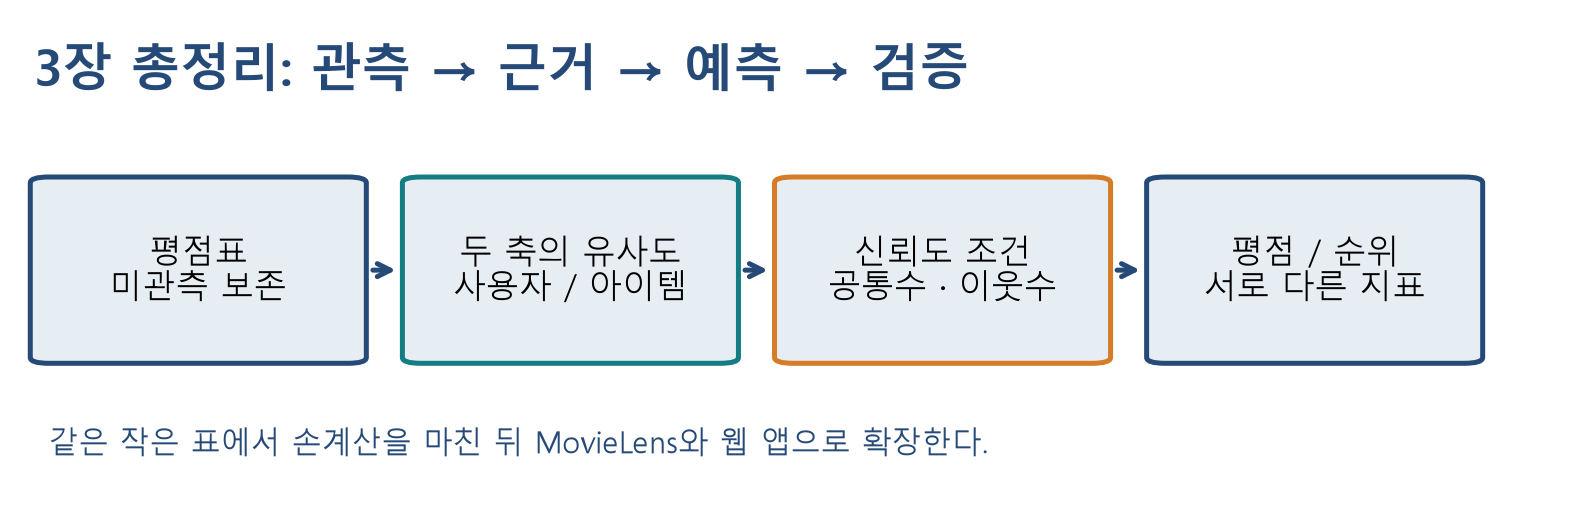


[Figure source](https://raw.githubusercontent.com/lunalab-ai/recommender/2026-fall-w04b/course/notion/assets/w04b/roadmap.png)


## 1. 환경과 독자 합성 관측 18개
`EvidenceCF`는 설정을 저장하고 `fit`에서 학습 통계를 구성한다. 신경망 학습은 아니다.
[모델·평가 정의](https://github.com/lunalab-ai/recommender/blob/2026-fall-w04b/src/luna_recsys/cf_synthesis.py#L13),
[앱·callback 정의](https://github.com/lunalab-ai/recommender/blob/2026-fall-w04b/src/luna_recsys/synthesis_app.py#L52).
클래스·함수 설명은 `help(EvidenceCF)` 또는 `inspect.getsource(EvidenceCF._terms)`로 실제 설치된 버전을 확인할 수 있다.
`toy_ratings()`는 user_id/movie_id/rating의 DataFrame을 반환한다. 실제 MovieLens 일부가 아니다.


In [ ]:
import os, sys, subprocess, inspect
os.environ['GRADIO_ANALYTICS_ENABLED']='False'
IN_COLAB='google.colab' in sys.modules
COURSE_VERSION='2026-fall-w04b'
if IN_COLAB:
    subprocess.run([sys.executable,'-m','pip','install','-q',
        f'luna-recommender-course[apps] @ git+https://github.com/lunalab-ai/recommender.git@{COURSE_VERSION}',
        'gradio==6.26.0'],check=True)
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gradio as gr
from IPython.display import display, HTML
from sklearn.metrics.pairwise import cosine_similarity
from luna_recsys.collaborative import toy_ratings, UserCF
from luna_recsys.cf_synthesis import EvidenceCF, rating_report, evaluate_cf
from luna_recsys.synthesis_app import CFLab, MODES, synthesis_view, build_synthesis_app
from luna_recsys.neighborhood import NeighborCF
from luna_recsys.neighborhood_app import build_neighbor_app
from luna_recsys.cf_app import build_cf_app
from luna_recsys.ranking import FourMethodRecommender, ranking_metrics
from luna_recsys.datasets import prepare_movielens
from luna_recsys.evaluation import split_ratings
toy=toy_ratings()
R=toy.pivot(index='user_id',columns='movie_id',values='rating')
display(R)
print('Python',sys.version.split()[0],'NumPy',np.__version__,'pandas',pd.__version__,'Gradio',gr.__version__)


표 만들기와 행렬곱 문법: [pandas pivot](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.pivot.html),
[NumPy matmul](https://numpy.org/doc/stable/reference/generated/numpy.matmul.html),
[cosine_similarity](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.cosine_similarity.html).

## 2. 마스크와 신뢰도 조건
R은 사용자×영화, M은 관측 여부를 정수 0/1로 표현한 같은 모양이다.
`M @ M.T`는 사용자 쌍의 공통 영화 수다. 반면 `M.T @ M`은 영화 쌍의 공통 사용자 수다.
코사인에서만 미관측을 0으로 채운다. 평균은 `R.mean(axis=1)`처럼 관측으로 계산한다.

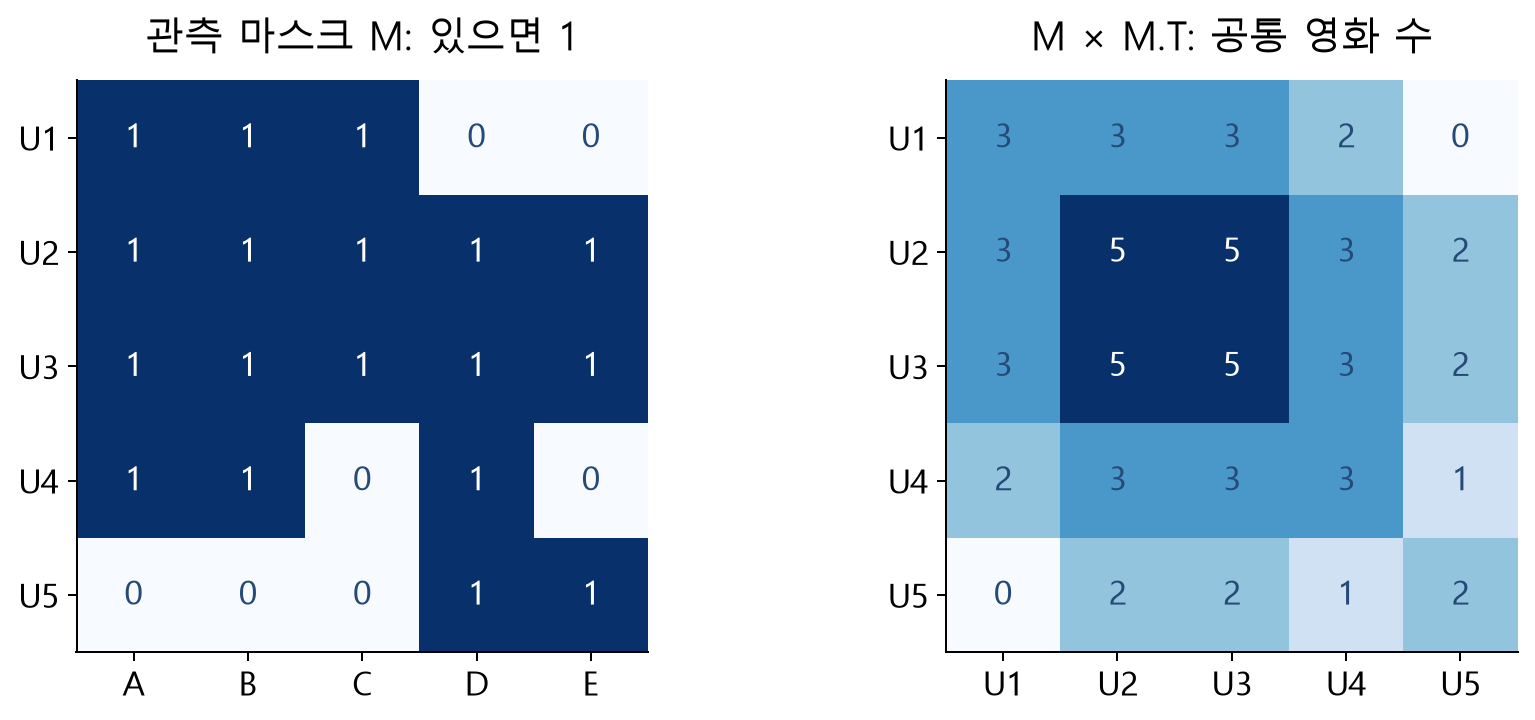


[Figure source](https://raw.githubusercontent.com/lunalab-ai/recommender/2026-fall-w04b/course/notion/assets/w04b/common-counts.png)


In [ ]:
M=R.notna().astype(int)
common=M @ M.T
display(common)
raw_cosine=pd.DataFrame(cosine_similarity(R.fillna(0)),index=R.index,columns=R.index)
display(raw_cosine.round(6))
print('U1-U4:',common.loc[1,4],'편; cosine=',raw_cosine.loc[1,4])


### E1 · 빈칸: 공통 평가 수
`common_e1`에 행렬곱을 넣고, U1–U4의 공통수를 `count_e1`에 넣으세요.
bool 행렬 대신 정수로 변환한 M을 쓰는 이유도 한 문장으로 적으세요.


In [ ]:
common_e1=None
count_e1=None
reason_e1=''
if common_e1 is not None:
    display(common_e1)


### 손계산을 코드의 각 연산으로 옮기기
U1–D의 후보 평가자 → 자기 자신 제외 → 양의 유사도 → 공통수 조건 → 정렬 → k개 순서다.
아래 코드는 핵심 알고리즘을 직접 풀어 쓴다. 전체 재사용 구현의 `_terms`는 여러 목표 영화를 함께 계산한다.
분자와 분모를 따로 확인한 뒤 마지막에 U1 평균을 더한다.

$u$는 대상, $v$는 이웃, $i$는 목표 영화, $N_{u,i}$는 유효 이웃 집합이다.
$s_{uv}$는 코사인, $\bar r_v$는 이웃의 학습 관측 평균이다.

$$
\hat r_{ui}=\bar r_u+\frac{\sum_{v\in N_{u,i}}s_{uv}(r_{vi}-\bar r_v)}{\sum_{v\in N_{u,i}}s_{uv}}
$$

공통수3·k2에서는 U2와 U3를 선택한다. 아래 코드의 numerator와 denominator는 다음 식의 분자·분모다.

$$
\hat r_{1D}=3+\frac{0.645423\times2.2+0.411201\times(-2)}{0.645423+0.411201}=3.565507
$$


In [ ]:
u,i,k,min_common,min_neighbors=1,4,2,3,2
candidates=R.index[(R[i].notna()) & (R.index!=u)]
table=pd.DataFrame({'similarity':raw_cosine.loc[u,candidates],
                    'common':common.loc[u,candidates],
                    'rating':R.loc[candidates,i],
                    'mean':R.mean(axis=1).loc[candidates]})
chosen=table.loc[(table.similarity>0)&(table.common>=min_common)].sort_values('similarity',ascending=False,kind='stable').head(k)
numerator=(chosen.similarity*(chosen.rating-chosen['mean'])).sum()
denominator=chosen.similarity.sum()
manual=float(R.loc[u].mean()+numerator/denominator) if len(chosen)>=min_neighbors else float(R.loc[u].mean())
display(chosen)
print('분자',numerator,'분모',denominator,'대상 평균',R.loc[u].mean(),'예측',manual)
small=EvidenceCF(k=2,min_common=3,min_neighbors=2,centered=True).fit(toy)
pair=pd.DataFrame({'user_id':[1],'movie_id':[4]})
display(small.predict_details(pair))
display(small.explain(1,4))


### Q1·Q2 · 계산을 해석하기
Q1: 평균 보정 전 이웃 U4의 가중치가 큰데, 보정 시 D의 예측을 올리지 않는 이유는?
Q2: `k=2, min_neighbors=3`이 통과 가능한가? 확보 이웃 수와 실제 사용 수를 구별하세요.


### E2 · 디버깅: 최소 2명과 `>2`
현재 `accepts_two`는 정확히 두 명을 거절합니다. “최소 2명”에 맞게 수정하고 설명하세요.
주교재 제공 코드의 `MIN_RATINGS=2`와 `>`를 읽을 때 생기는 경계 차이입니다.


In [ ]:
def accepts_two(count):
    return count>2
boundary_e2=[accepts_two(n) for n in [1,2,3]]
print('현재 경계 동작:',boundary_e2)
explanation_e2=''


## 3. 아이템 CF: 축과 평점의 주인을 함께 바꾸기
영화 D의 벡터는 사용자 순서로 [0,5,1,4,2], A는 [5,4,1,5,0]이다.
D–A 내적은 41, 노름 제곱은 46과 67. U1이 관측한 A·B·C 중 상위 두 편을 골라
**U1 자신의** A=5, B=3을 가중평균한다. 결과는 4.054617이다.
$J_{u,i}$는 사용자가 평가한 영화 중 선택된 이웃 영화 집합이다.

$$
s_{DA}=\frac{41}{\sqrt{46}\sqrt{67}},\qquad
\hat r_{ui}=\frac{\sum_{j\in J_{u,i}}s_{ij}r_{uj}}{\sum_{j\in J_{u,i}}s_{ij}}
$$

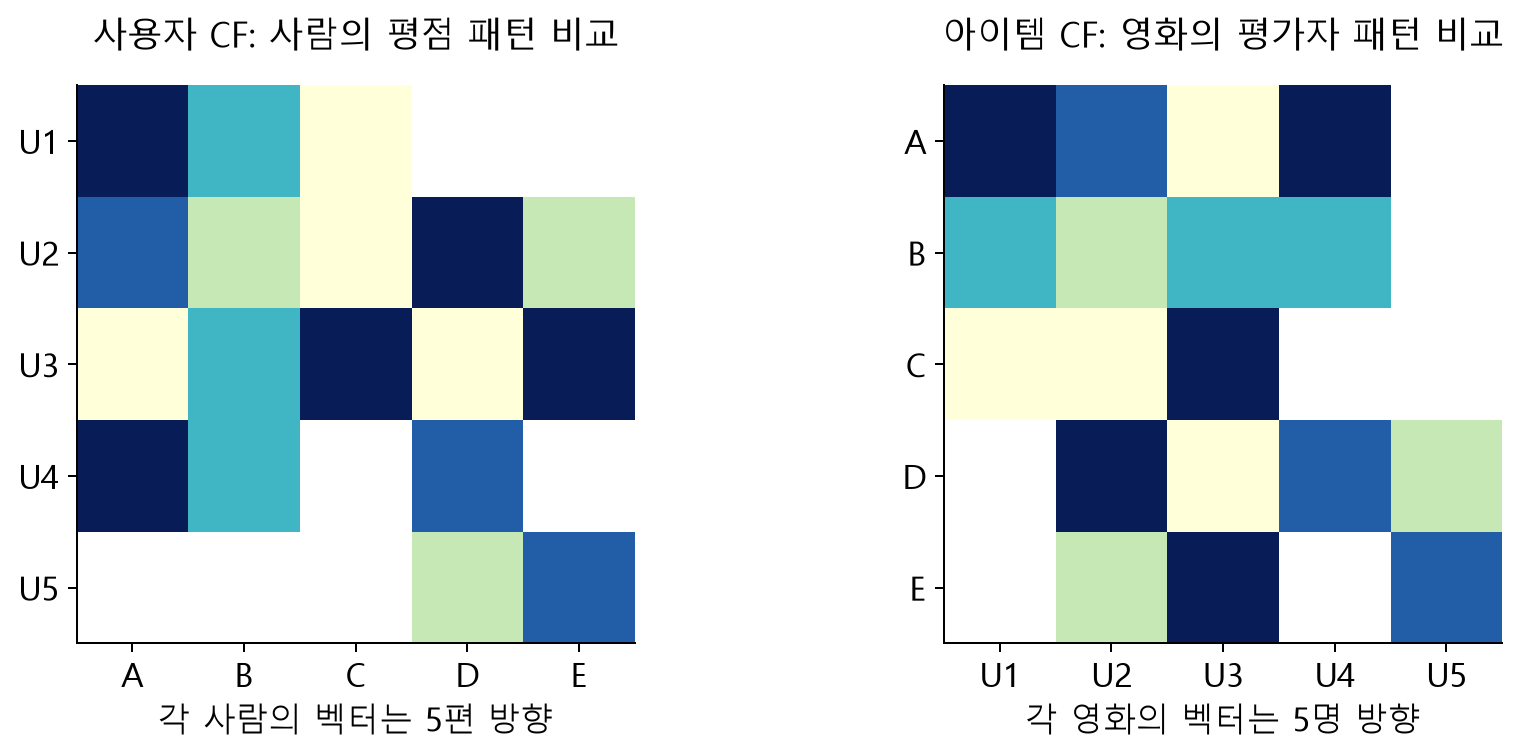


[Figure source](https://raw.githubusercontent.com/lunalab-ai/recommender/2026-fall-w04b/course/notion/assets/w04b/two-axes.png)


In [ ]:
item_vectors=R.fillna(0).T
item_similarity=pd.DataFrame(cosine_similarity(item_vectors),index=R.columns,columns=R.columns)
seen=R.loc[1].dropna()
neighbors=item_similarity.loc[4,seen.index].sort_values(ascending=False).head(2)
item_manual=float((neighbors*seen.loc[neighbors.index]).sum()/neighbors.sum())
item_model=EvidenceCF(axis='item',k=2).fit(toy)
display(item_model.explain(1,4))
print('아이템 손계산',item_manual,'; similarity shape',item_model.similarity_.shape)


### E3 · 빈칸: 아이템 벡터와 코사인
`vectors_e3`에 영화별 사용자 벡터를, `s_da_e3`에 D–A 코사인을 직접 계산하여 넣으세요.
**Q3:** 전치하면 이웃 ID와 common_counts의 단위는 각각 어떻게 바뀌나요?


In [ ]:
vectors_e3=None
s_da_e3=None
units_e3=''
if vectors_e3 is not None:
    display(vectors_e3)


## 4. 평점 오차·혼동행렬·순위·coverage
실제 [5,2,4,1], 예측 [4,3,4,3]의 절대오차 합은 4, 제곱오차 합은 6이다.
MAE=1, MSE=1.5, RMSE=sqrt(1.5). 주교재 MAD는 여기서 MAE와 같은 의미다.
`ranking_metrics(recommended, relevant, k)`는 ID 목록, 관련 ID 집합, 양의 정수 k를 받고
P/R/NDCG/hits dict를 반환한다. 순서를 보존하며 파일·학습 부작용은 없다.
사용자별 F1을 구한 뒤 평균한다. 평균 P/R로 계산한 F1과 다를 수 있다.
평가 관측 개수를 $m$이라 하면 다음처럼 절대값·제곱을 취한 뒤 평균을 낸다.

$$
\mathrm{MAE}=\frac{1}{m}\sum_{t=1}^{m}|r_t-\hat r_t|,\qquad
\mathrm{RMSE}=\sqrt{\frac{1}{m}\sum_{t=1}^{m}(r_t-\hat r_t)^2}
$$

$$
P=\frac{TP}{TP+FP},\quad R=\frac{TP}{TP+FN},\quad F_1=\frac{2PR}{P+R}
$$

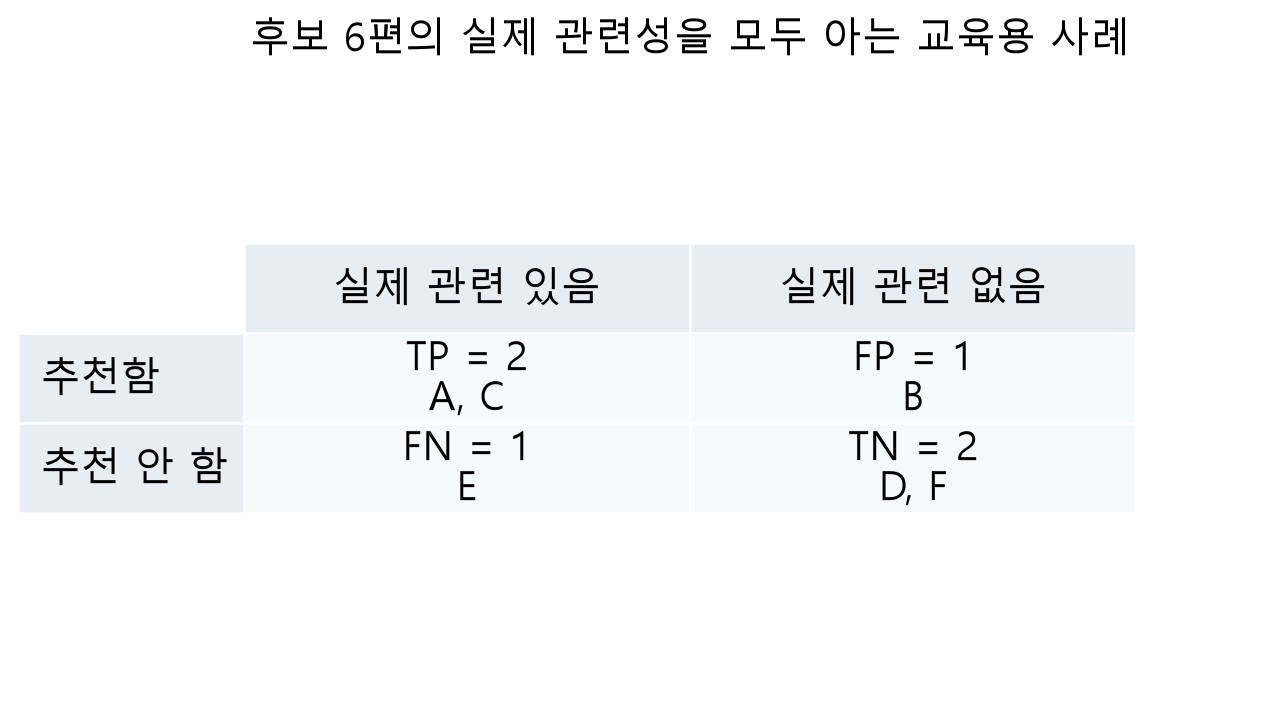


[Figure source](https://raw.githubusercontent.com/lunalab-ai/recommender/2026-fall-w04b/course/notion/assets/w04b/confusion.png)


In [ ]:
actual=np.array([5,2,4,1]);predicted=np.array([4,3,4,3])
error=actual-predicted
print('MAE',np.abs(error).mean(),'MSE',(error**2).mean(),'RMSE',np.sqrt((error**2).mean()))
truth={'A','C','E'}
metrics3=ranking_metrics(['A','B','C'],truth,k=3)
display(metrics3)
print('Accuracy',(2+2)/6,'TPR',2/3,'FPR',1/3)
raw=np.array([5.8,.4]);bounded=np.clip(raw,1,5);truth_rating=np.array([4,2])
print('clip 전/후 MAE:',np.abs(raw-truth_rating).mean(),np.abs(bounded-truth_rating).mean())


### E4 · 예측·계산: N만 늘리기
관련 영화 {A,C,E}, 순서 [A,B,C,D,E,F]입니다. Top-3와 Top-4의 P/R/F1을 계산하세요.
N을 늘리면 precision이 반드시 감소하는지도 Top-5를 보고 설명하세요.


In [ ]:
metrics_e4=None
explanation_e4=''
if metrics_e4 is not None:
    display(metrics_e4)


## 5. 봉투에 둔 합성 정답으로 총정리
toy 관측 18개는 유지한다. U1–D=5, U1–E=2는 **이번 평가만을 위해 새로 정한 합성 정답**이다.
fit에 넣지 않는다. 영화 카탈로그는 ID/title 표이며 중복 ID가 없어야 한다.
아래 네 방식은 평점 오차가 다르지만 Top-1은 모두 D일 수 있다.


In [ ]:
toy_movies=pd.DataFrame({'movie_id':range(1,6),'title':list('ABCDE')})
toy_holdout=pd.DataFrame({'user_id':[1,1],'movie_id':[4,5],'rating':[5,2]})
toy_settings=[dict(k=2),dict(k=2,centered=True),dict(k=2,centered=True,min_common=3,min_neighbors=2),dict(axis='item',k=2)]
toy_models=[EvidenceCF(**s).fit(toy) for s in toy_settings]
toy_reports=[evaluate_cf(m,toy_holdout,toy_movies,top_n=1) for m in toy_models]
display(pd.DataFrame([{'setting':str(s),**m} for s,m in zip(toy_settings,toy_reports)]))


### Q4 · 이 예제의 한계를 말하기
공통수 조건을 적용한 D 예측이 합성 정답 5에서 더 멀어졌습니다.
이 한 사례로 그 조건을 항상 제거해야 한다고 말할 수 있을까요?


In [ ]:
assert len(toy)==18 and R.isna().sum().sum()==7
assert np.isclose(manual,small.predict(pair)[0])
assert np.isclose(item_manual,item_model.predict(pair)[0])
assert all(np.isclose(r['precision'],1) for r in toy_reports)
assert not toy.set_index(['user_id','movie_id']).index.intersection(toy_holdout.set_index(['user_id','movie_id']).index).size
assert np.isclose(metrics3['ndcg'],1.5/(1+1/np.log2(3)+.5))
print('작은 예제와 독립 손계산 일치')


## 6. 실제 데이터와 60/20/20 분리
`prepare_movielens(Path,mode='real')`는 최초 다운로드 후 캐시를 재사용한다. 반환의 `.data`는
users/movies/ratings 표, `.mode`는 실제 출처 이름이다. 실데이터 실패는 오류로 드러낸다.
합성 시연이 필요할 때만 아래 DATA_MODE를 `'synthetic'`으로 명시적으로 바꾼다.
합성 결과를 강의의 MovieLens 실측값으로 보고하지 않는다. 네트워크 실패 후 자동 대체는 없다.
`split_ratings`의 test_size=.25는 입력 80%의 25%이므로 전체의 20%다.

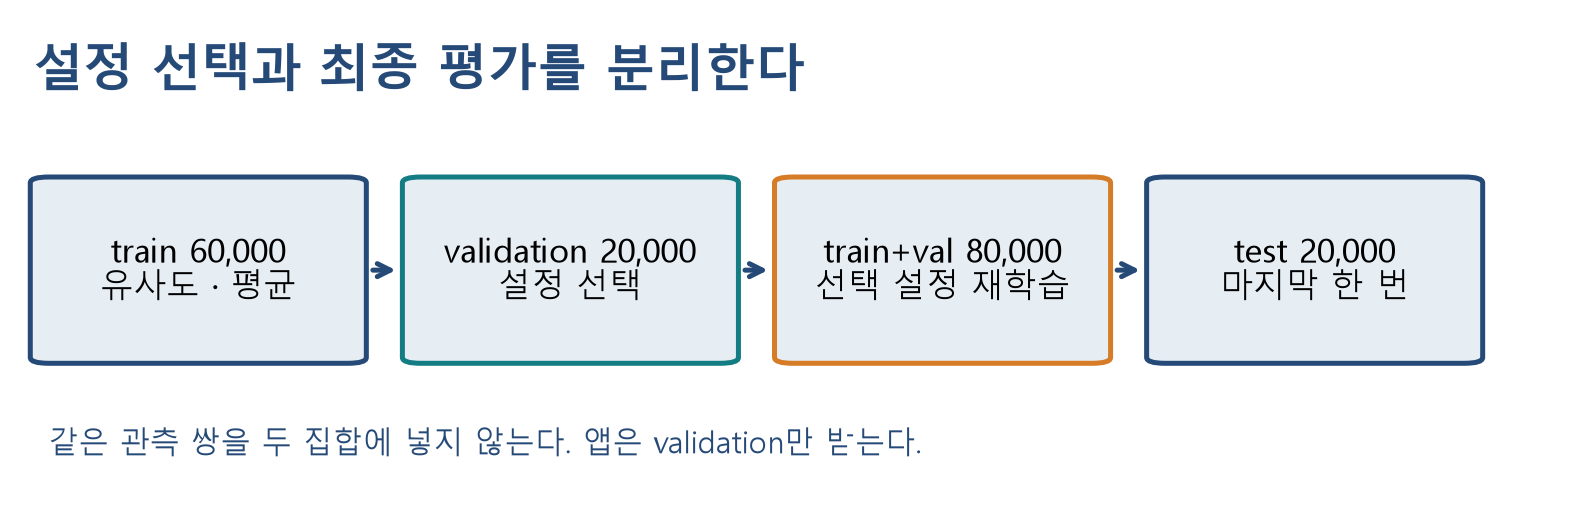


[Figure source](https://raw.githubusercontent.com/lunalab-ai/recommender/2026-fall-w04b/course/notion/assets/w04b/validation-flow.png)


In [ ]:
DATA_MODE='real'
prepared=prepare_movielens(Path('data/local/w04b'),mode=DATA_MODE)
data=prepared.data
outer=split_ratings(data.ratings,test_size=.2,seed=20260922)
inner=split_ratings(outer.train,test_size=.25,seed=20260923)
train,validation,test=inner.train,inner.test,outer.test
print('데이터 모드:',prepared.mode,prepared.description)
print('train / validation / test:',len(train),len(validation),len(test))
lab=CFLab(train,validation,data.movies,rank_limit=40,seed=20260923,data_label=prepared.mode)
print('고정 순위 표본:',len(lab.ranking_users),'명 · 평점 평가는 validation 전체')


### 6.1 학습 상태와 평가 함수
사용자 similarity는 U×U, 아이템 similarity는 I×I. 학습에 관측된 영화만 행렬에 있지만
평가 카탈로그는 전체다. 학습에 없는 영화는 명시한 평균 fallback으로 처리한다.
`configured`는 k/common/minimum/centered/clip을 바꾼 새 설정 객체를 반환한다.
학습 배열을 공유하므로 fit을 반복하지 않는다. 원모델과 입력 자료는 바꾸지 않는다.
`rating_report`는 중복·train 겹침을 거부하고 MAE/MSE/RMSE/근거 비율을 계산한다.
`evaluate_cf`는 같은 평점 평가와 순위 평가를 함께 반환한다. 순위 후보는 전체 카탈로그에서
학습 이력만 제외하며 관련 영화는 heldout의 4점 이상이다. 미관측은 실제 비선호가 아니다.


In [ ]:
print('사용자 유사도:',lab.models['user'].similarity_.shape)
print('아이템 유사도:',lab.models['item'].similarity_.shape)
presets=[dict(axis='user',centered=False,k=0,min_common=1,min_neighbors=1,clip=True),
         dict(axis='user',centered=True,k=30,min_common=1,min_neighbors=1,clip=True),
         dict(axis='user',centered=True,k=30,min_common=3,min_neighbors=2,clip=True),
         dict(axis='item',centered=False,k=30,min_common=1,min_neighbors=1,clip=True)]
preset_results=[]
for s in presets:
    model=lab.models[s['axis']].configured(**{k:v for k,v in s.items() if k!='axis'})
    result=evaluate_cf(model,validation,data.movies,top_n=10,ranking_users=lab.ranking_users)
    preset_results.append(dict(settings=s,metrics=result))
display(pd.DataFrame([{**r['settings'],**r['metrics']} for r in preset_results]))


### 6.2 검증 설정 탐색
평균 보정 사용자 CF에서 k만 바꾸는 네 행과, k=30·최소2에서 공통수만 바꾸는 네 행이다.
설정은 이 여덟 행과 앞의 네 기본 구성 중 validation RMSE 최소로 고른다.
근거 coverage가 줄었는데 RMSE만 소폭 개선되었다면 그 비용도 함께 해석한다.


In [ ]:
sweep=[]
grid=[(k,1,1) for k in [5,10,30,60]]+[(30,c,2) for c in [3,5,10,20]]
for k,common_count,minimum in grid:
    settings=dict(axis='user',centered=True,k=k,min_common=common_count,min_neighbors=minimum,clip=True)
    model=lab.models['user'].configured(**{k:v for k,v in settings.items() if k!='axis'})
    sweep.append(dict(settings=settings,metrics=rating_report(model,validation)))
sweep_table=pd.DataFrame([{**r['settings'],**r['metrics']} for r in sweep])
display(sweep_table)
fig,axes=plt.subplots(1,2,figsize=(10,3))
for ax,rows,x in [(axes[0],sweep_table.iloc[:4],'k'),(axes[1],sweep_table.iloc[4:],'min_common')]:
    ax.plot(rows[x],rows.rmse,'-o');ax.set(xlabel=x,ylabel='Validation RMSE');ax.grid(alpha=.2)
plt.show()
selected=min(preset_results+sweep,key=lambda r:r['metrics']['rmse'])['settings'].copy()
print('설정 선택 완료:',selected)


### E5 · 예측·비교: 근거 하한을 바꾸기
사용자 평균 보정·k30·최소2를 고정하고 min_common을 1→3→10으로 바꿉니다.
먼저 RMSE·CF 근거 비율·첫 추천의 근거가 어떻게 바뀔지 예상하세요. test는 사용하지 않습니다.
결과를 얻은 뒤 “항상 개선”이라는 표현 대신 관측값과 한계를 적으세요.


In [ ]:
prediction_e5=''
results_e5=None
interpretation_e5=''
if results_e5 is not None:
    display(results_e5)


### 6.3 선택을 끝낸 뒤 최종 test 한 번
아래 셀은 선택된 설정으로 train+validation을 다시 학습하고 test를 한 번 평가한다.
결과를 본 뒤 설정 선택 셀로 돌아가서 성능을 맞추지 않는다. 학습 자료가 커졌으므로
검증과 최종 test의 값 차이를 순수한 설정 효과로 해석하지 않는다.


In [ ]:
final_model=EvidenceCF(**selected).fit(outer.train)
final_test=evaluate_cf(final_model,test,data.movies,top_n=10,ranking_users=lab.ranking_users)
display(pd.DataFrame([final_test]))
print('최종 test 완료. 이후 앱은 test를 받지 않습니다.')


In [ ]:
def pair_ids(frame):
    return set(zip(frame.user_id,frame.movie_id))
assert not pair_ids(train)&pair_ids(validation)
assert not pair_ids(outer.train)&pair_ids(test)
if DATA_MODE=='real':
    assert prepared.mode=='movielens'
    assert (len(train),len(validation),len(test))==(60000,20000,20000)
    assert (len(data.users),len(data.movies))==(943,1682)
assert all(np.isfinite(r['metrics']['rmse']) for r in preset_results+sweep)
assert final_test['rating_count']==len(test) and final_test['ranking_users']>0
assert all(0<=final_test[k]<=1 for k in ['precision','recall','f1','ndcg','cf_coverage','catalog_coverage'])
print('실제 데이터 분리·예측·최종 평가 확인')


## 7. 같은 계산을 누적 웹 앱에 연결하기
`synthesis_view(lab,mode,user_id,k,min_common,min_neighbors,clip,top_n,history=None)`는
HTML, 추천 DataFrame, 전체 근거 DataFrame, 비교 DataFrame, 새 기록 list, Figure의 6개를 반환한다.
이전 history를 직접 바꾸지 않는다. `CFLab.metrics`는 같은 설정의 검증 결과를 캐시한다.
선택한 사용자는 개별 추천을 바꾸지만 검증 지표의 고정 사용자 표본은 바꾸지 않는다.
첫 계산에는 전체 검증 평점과 순위 표본을 평가하는 시간이 든다.
그림은 최대20개+나머지 합, 표는 전체 이웃을 제공한다. 희소한 첫 추천이 평균 대체라면 빈 근거표가 정상이다.

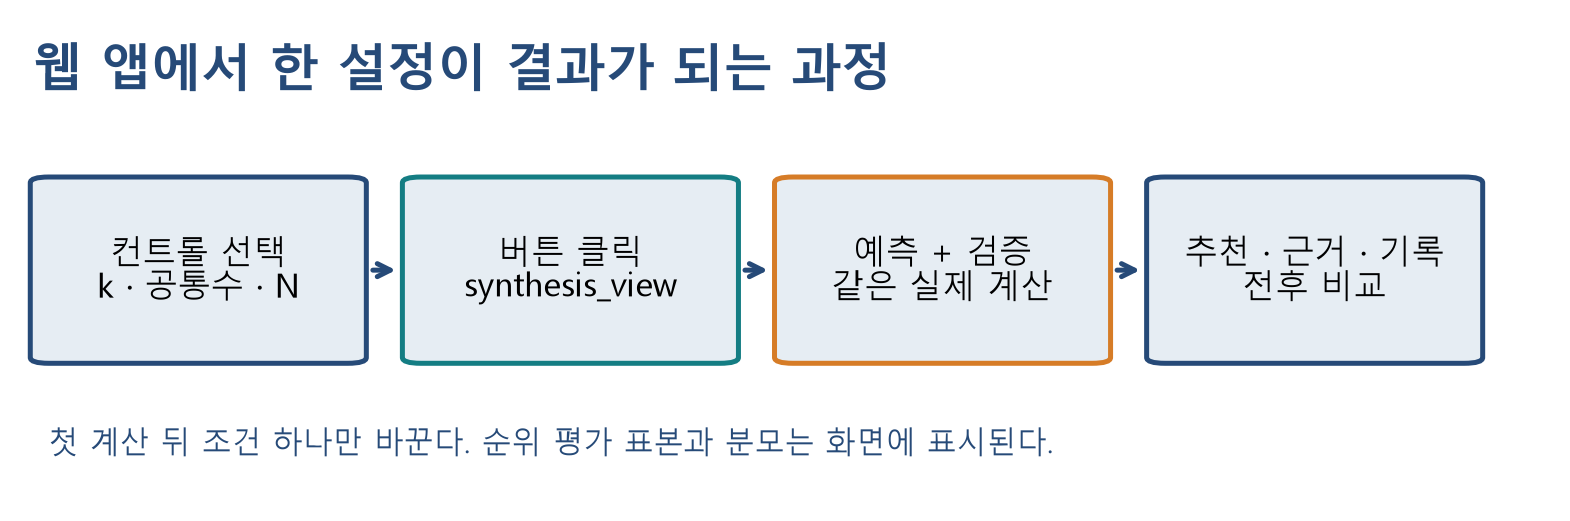


[Figure source](https://raw.githubusercontent.com/lunalab-ai/recommender/2026-fall-w04b/course/notion/assets/w04b/app-flow.png)


In [ ]:
view=synthesis_view(lab,MODES[1],1,30,3,2,True,5)
display(HTML(view[0]),view[1],view[3],view[5])
print('첫 추천 전체 이웃:',len(view[2]),'개')


### E6 · 버튼 callback 연결
아래 작은 앱의 버튼에 `demo_callback`을 연결하세요. 입력은 minimum, 출력은 demo_summary와 demo_table입니다.
minimum을 1→3으로 바꾸고 버튼을 누르면 실제 예측과 basis가 함께 갱신되어야 합니다.
이 작은 활동은 전체 앱과 별개라 미완성 상태여도 마지막 누적 앱을 실행할 수 있습니다.


In [ ]:
def demo_callback(minimum):
    model=EvidenceCF(k=2,min_common=3,min_neighbors=int(minimum),centered=True).fit(toy)
    result=model.predict_details(pair)
    return f"예측 {result.iloc[0].prediction:.4f} · {result.iloc[0].basis}",result
with gr.Blocks() as exercise_app:
    minimum=gr.Slider(1,3,value=1,step=1,label='최소 이웃')
    demo_button=gr.Button('예측 계산')
    demo_summary=gr.Markdown()
    demo_table=gr.Dataframe(interactive=False)
    # 여기에 demo_button.click(...) 연결문을 작성하세요.


### 7.1 이전 수업 앱을 보존하여 합치기
`FourMethodRecommender.fit(train,users,movies)`는 앞선 네 방법 비교의 학습 상태,
`build_cf_app`은 기본 CF, `build_neighbor_app`은 k·평균 보정 앱을 반환한다.
`legacy`에 차례로 전달하면 지난 앱이 하위 탭에 유지된다. 반환형은 모두 실행 전 Blocks다.
서버는 마지막 셀의 `launch`에서만 시작한다. 이 앱은 validation 학습 상태를 사용한다.


In [ ]:
four=FourMethodRecommender().fit(train,data.users,data.movies)
base_app=build_cf_app(UserCF().fit(train),data.movies,comparison=four)
neighbor_app=build_neighbor_app(NeighborCF(k=30,centered=True).fit(train),data.movies,legacy=base_app)
app=build_synthesis_app(lab,legacy=neighbor_app)
print('누적 앱 생성 완료:',type(app).__name__)


In [ ]:
second_view=synthesis_view(lab,MODES[2],1,30,3,2,True,5,view[4])
assert len(view[1])==5 and len(second_view[1])==5
assert len(view[4])==1 and len(second_view[4])==2
assert np.isfinite(second_view[1].prediction).all()
assert set(second_view[1].movie_id).isdisjoint(lab.models['item'].seen_[1])
assert isinstance(app,gr.Blocks) and len(app.config['dependencies'])>1
first_model=lab.model(MODES[1],30,3,2,True)
if len(view[2]):
    explained=float(view[2].contribution.sum()+first_model.user_means_.loc[1])
    assert np.isclose(explained,view[1].iloc[0].raw_prediction,atol=1e-4)
print('실데이터 두 축 callback·세션 기록·누적 앱 이벤트 확인')


### 7.2 웹에서 조작하고 비교하기
사용자·N을 고정하고 k 5→30→60, 이후 k30에서 공통수 1→3→10을 바꿔 기록한다.
최소 이웃과 clip도 한 번에 하나씩 바꾼다. 마지막에 방식·N을 비교한다.
제목, 근거 수, fallback, RMSE, P/R/F1, NDCG, coverage를 함께 읽는다.
화면의 평점 관측 수와 순위 표본 수는 다르다. 관련 영화 없는 사용자 제외 수도 확인한다.
Colab에서는 아래 셀이 공유 주소를 제공한다. 런타임 종료 후 임시 주소는 만료되므로 다시 실행한다.
로컬 검토에서는 `app.launch()`로 직접 실행한다. 자동 검증은 서버를 열지 않고 callback과 Blocks를 검증한다.


In [ ]:
if IN_COLAB:
    app.launch(share=True,debug=False)
else:
    print('로컬 웹 실행: app.launch() · 자동 실행 검증에서는 서버를 시작하지 않습니다.')


## 핵심 정리
공통수는 이웃 쌍, 최소 이웃은 한 예측의 근거다. 사용자 CF는 다른 사람의 목표 평점,
아이템 CF는 대상 사용자의 비슷한 영화 평점을 집계한다. 평점 오차와 목록 적중은 다른 질문이다.
coverage는 반드시 분모와 함께 보고한다. 설정은 validation에서 고르고 test는 마지막에만 쓴다.

주교재3.7–3.9를 바탕으로 독자 예제와 코드를 만들었다. NDCG·검증·앱 구현은 추가 설명이다.
[MovieLens100K](https://grouplens.org/datasets/movielens/100k/) ·
[Surprise KNN](https://surprise.readthedocs.io/en/stable/knn_inspired.html) ·
[Stanford IR 평가](https://nlp.stanford.edu/IR-book/html/htmledition/evaluation-of-unranked-retrieval-sets-1.html)
자료 확인: 2026-09-23. 실제 Colab와 공개 태그 설치 확인은 로컬 실행 검사와 별개다.
